**From Cristian**

In [1]:
# Import necessary libraries
import os
from datasets import load_dataset, Dataset, DatasetDict
#import torch
#from transformers import AutoTokenizer
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import h5py

# Optional: Set Hugging Face cache directory
# os.environ["HF_DATASETS_CACHE"] = "/path/to/your/cache"

print("Libraries imported successfully!")
#print(f"Torch version: {torch.__version__}")
#print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")


Libraries imported successfully!


In [2]:
# Load a simple text dataset
print("Loading SO101 dataset...")
dataset = load_dataset("1lyz123576/so101_test")
ds_1 = load_dataset("smanni/train_so100_all")
ds_2 = load_dataset("bjb7/so101_pen_touch_test_1")
ds_3 = load_dataset("shreyasgite/so100_base_env")

# Explore the dataset structure
print(f"Dataset: {dataset}")
print(f"Dataset keys: {dataset.keys()}")

Loading SO101 dataset...


Resolving data files:   0%|          | 0/135 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/135 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/900 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/900 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/252 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/252 [00:00<?, ?it/s]

Dataset: DatasetDict({
    train: Dataset({
        features: ['action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
        num_rows: 64505
    })
})
Dataset keys: dict_keys(['train'])


In [4]:
# Explore the dataset structure
output_path = "./output/converted.h5"
print(f"Dataset: {dataset}")
print(f"Dataset keys: {dataset.keys()}")
print(f"Dataset features: {dataset['train'].features['action']}")

print(f"🔄 Converting dataset to H5 format: {output_path}")
print(f"📊 Dataset size: {len(dataset)}")

Dataset: DatasetDict({
    train: Dataset({
        features: ['action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'],
        num_rows: 64505
    })
})
Dataset keys: dict_keys(['train'])
Dataset features: List(Value('float32'), length=6)
🔄 Converting dataset to H5 format: ./output/converted.h5
📊 Dataset size: 1


In [29]:
def convert_dataset_to_h5(dataset, output_path):
    """
    Convert Hugging Face dataset to H5 format with episodic dictionary structure.
    
    Expected output structure: Dictionary with episode keys '0', '1', ..., 'N_episodes-1'
    Each episode contains data with its actual length (no padding needed).
    Timestamps and frame indices are computed on the fly based on 30 FPS data.
    
    Expected H5 structure:
    - observation/robot_state/cartesian_position/{episode_id}: (Length_episode, N_joints)
    - observation/robot_state/gripper_position/{episode_id}: (Length_episode, N_joints)
    - metadata/timestamp/{episode_id}: (Length_episode,)
    - metadata/frame_index/{episode_id}: (Length_episode,)
    """
    print(f"🔄 Converting dataset to H5 format with episodic dictionary structure: {output_path}")
    print(f"📊 Dataset size: {len(dataset)}")
    
    # Check if episode_index exists to determine episode structure
    if 'episode_index' not in dataset[0]:
        raise ValueError("Episode structure required: dataset must contain 'episode_index' field")
    
    # Extract episode indices and determine structure
    action_key='action'
    state_key='observation.state'
    fps=30
    episode_indices = np.array([sample['episode_index'] for sample in dataset])
    unique_episodes = np.unique(episode_indices)
    n_episodes = len(unique_episodes)
    
    # Calculate episode lengths
    episode_lengths = [np.sum(episode_indices == ep) for ep in unique_episodes]
    
    print(f"✅ Found {n_episodes} episodes")
    print(f"📊 Episode lengths: min={min(episode_lengths)}, max={max(episode_lengths)}, mean={np.mean(episode_lengths):.1f}")
    
    # Extract joint positions from dataset
    if state_key in dataset[0]:
        joint_data_flat = np.array([sample[state_key] for sample in dataset])
        n_joints = joint_data_flat.shape[1]
        print(f"✅ Found joint positions: {joint_data_flat.shape} -> creating dictionary structure")
    else:
        print(f"⚠️  {state_key} not found, creating synthetic joint data")
        n_joints = 6
        joint_data_flat = np.random.randn(len(dataset), n_joints).astype(np.float64)
    
    # Extract or create gripper positions
    if action_key in dataset[0]:
        gripper_data_flat = np.array([sample[action_key] for sample in dataset])
        if len(gripper_data_flat.shape) == 1:
            gripper_data_flat = gripper_data_flat.reshape(-1, 1)
        elif gripper_data_flat.shape[1] != n_joints:
            # Resize to match joint dimensions or use appropriate action dimensions
            if gripper_data_flat.shape[1] > n_joints:
                gripper_data_flat = gripper_data_flat[:, :n_joints]
            else:
                # Pad with zeros if needed
                padding = np.zeros((len(dataset), n_joints - gripper_data_flat.shape[1]))
                gripper_data_flat = np.concatenate([gripper_data_flat, padding], axis=1)
        print(f"✅ Found gripper data: {gripper_data_flat.shape}")
    else:
        print(f"⚠️  Creating synthetic gripper data")
        gripper_data_flat = np.random.rand(len(dataset), n_joints).astype(np.float64) * 0.02
    
    # Create episodic dictionary structure
    print(f"🔄 Creating episodic dictionary structure...")
    
    # Initialize dictionaries with episode keys as strings
    joint_positions = {}
    gripper_positions = {}
    timestamps = {}
    frame_indices = {}
    
    # Fill dictionaries episode by episode
    for i, episode_id in enumerate(unique_episodes):
        episode_key = str(i)  # Use string index as key: '0', '1', '2', etc.
        
        # Find indices for this episode
        episode_mask = episode_indices == episode_id
        episode_length = np.sum(episode_mask)
        
        # Extract episode data with actual episode length
        episode_joint_data = joint_data_flat[episode_mask]
        episode_gripper_data = gripper_data_flat[episode_mask]
        
        # Store data with actual episode length (no padding)
        joint_positions[episode_key] = episode_joint_data.astype(np.float64)
        gripper_positions[episode_key] = episode_gripper_data.astype(np.float64)
        
        # Compute frame indices and timestamps for this episode
        frame_indices[episode_key] = np.arange(episode_length, dtype=np.int64)
        timestamps[episode_key] = np.arange(episode_length, dtype=np.float32) / fps
        
        
    print(f"✅ Created episodic dictionary structure:")
    print(f"   📊 Number of episodes: {len(joint_positions)}")
    print(f"   📊 Episode keys: {list(joint_positions.keys())}")
    print(f"   📊 Episode lengths: {[joint_positions[k].shape[0] for k in joint_positions.keys()]}")
    print(f"   📊 Joint dimensions: {n_joints}")
    
    # Create H5 file with episodic dictionary structure
    with h5py.File(output_path, 'w') as f:
        # Create groups to match expected structure
        metadata_group = f.create_group('metadata')
        observation_group = f.create_group('observation')
        robot_state_group = observation_group.create_group('robot_state')
        
        # Create subgroups for each data type
        cartesian_group = robot_state_group.create_group('cartesian_position')
        gripper_group = robot_state_group.create_group('gripper_position')
        timestamp_group = metadata_group.create_group('timestamp')
        frame_index_group = metadata_group.create_group('frame_index')
        
        # Store data for each episode separately
        for episode_key in joint_positions.keys():
            cartesian_group.create_dataset(episode_key, data=joint_positions[episode_key])
            gripper_group.create_dataset(episode_key, data=gripper_positions[episode_key])
            timestamp_group.create_dataset(episode_key, data=timestamps[episode_key])
            frame_index_group.create_dataset(episode_key, data=frame_indices[episode_key])
        
        print(f"✅ Saved H5 file with episodic dictionary structure:")
        print(f"   📊 observation/robot_state/cartesian_position/{{episode_id}}: Individual episode shapes")
        print(f"   📊 observation/robot_state/gripper_position/{{episode_id}}: Individual episode shapes")
        print(f"   📊 metadata/timestamp/{{episode_id}}: Individual episode shapes")
        print(f"   📊 metadata/frame_index/{{episode_id}}: Individual episode shapes")
        print(f"   📊 N_episodes: {n_episodes}, N_joints: {n_joints}")
        
        # Show shapes for first few episodes
        for i, episode_key in enumerate(list(joint_positions.keys())[:3]):
            print(f"   📊 Episode '{episode_key}': joints {joint_positions[episode_key].shape}, timestamps {timestamps[episode_key].shape}")
        
        if len(joint_positions) > 3:
            print(f"   📊 ... and {len(joint_positions) - 3} more episodes")
            
        # Print data range
        all_joint_data = np.concatenate([joint_positions[k] for k in joint_positions.keys()], axis=0)
        print(f"   Range: [{all_joint_data.min():.3f}, {all_joint_data.max():.3f}] radians")

# Test the new episodic conversion function
print("🧪 Testing episodic conversion with current dataset...")
output_file_episodic = "./output/converted_episodic.h5"
convert_dataset_to_h5(dataset['train'], output_file_episodic)
print(f"🎉 Episodic conversion completed!")

# Verify the episodic dictionary structure
def verify_h5_structure(h5_path):
    """Verify the H5 file has the correct episodic dictionary structure."""
    print(f"🔍 Verifying episodic dictionary H5 structure: {h5_path}")
    
    with h5py.File(h5_path, 'r') as f:
        print(f"📁 H5 file groups and datasets:")
        
        def print_structure(name, obj):
            if isinstance(obj, h5py.Group):
                print(f"   📁 Group: {name}")
            elif isinstance(obj, h5py.Dataset):
                print(f"   📊 Dataset: {name} {obj.shape} {obj.dtype}")
        
        f.visititems(print_structure)
        
        # Test access to episodic dictionary data
        cartesian_group = f['observation/robot_state/cartesian_position']
        gripper_group = f['observation/robot_state/gripper_position']
        timestamp_group = f['metadata/timestamp']
        frame_index_group = f['metadata/frame_index']
        
        # Get episode keys
        episode_keys = list(cartesian_group.keys())
        n_episodes = len(episode_keys)
        
        print(f"\\n🎯 Episodic dictionary data verification:")
        print(f"   📊 Number of episodes: {n_episodes}")
        print(f"   📊 Episode keys: {episode_keys}")
        
        # Verify structure for each episode
        for i, episode_key in enumerate(episode_keys[:3]):  # Show first 3 episodes
            joint_data = cartesian_group[episode_key]
            gripper_data = gripper_group[episode_key]
            timestamp_data = timestamp_group[episode_key]
            frame_index_data = frame_index_group[episode_key]
            
            # Show sample data
        print(f"      First 3 frames:")
        print(f"         Joint positions: {joint_data[:3]}")
        print(f"         Timestamps: {timestamp_data[:3]}")
        print(f"         Frame indices: {frame_index_data[:3]}")
        
        if n_episodes > 3:
            print(f"\\n   📊 ... and {n_episodes - 3} more episodes")
            
        # Show episode length distribution
        episode_lengths = [cartesian_group[key].shape[0] for key in episode_keys]
        print(f"\\n   📊 Episode length distribution:")
        print(f"      Min: {min(episode_lengths)}, Max: {max(episode_lengths)}, Mean: {np.mean(episode_lengths):.1f}")
        
       

verify_h5_structure(output_file_episodic)


🧪 Testing episodic conversion with current dataset...
🔄 Converting dataset to H5 format with episodic dictionary structure: ./output/converted_episodic.h5
📊 Dataset size: 64505
✅ Found 135 episodes
📊 Episode lengths: min=211, max=894, mean=477.8
✅ Found joint positions: (64505, 6) -> creating dictionary structure
✅ Found gripper data: (64505, 6)
🔄 Creating episodic dictionary structure...
✅ Created episodic dictionary structure:
   📊 Number of episodes: 135
   📊 Episode keys: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', 

Shape of joint positions data: (548, 6)
📐 Plotting 548 frames (18.2 seconds)
📊 Gripper positions: (548, 6)
📊 Joint positions: (548, 6)
📊 Timestamps: (548,)
📊 Frame indices: (548,)


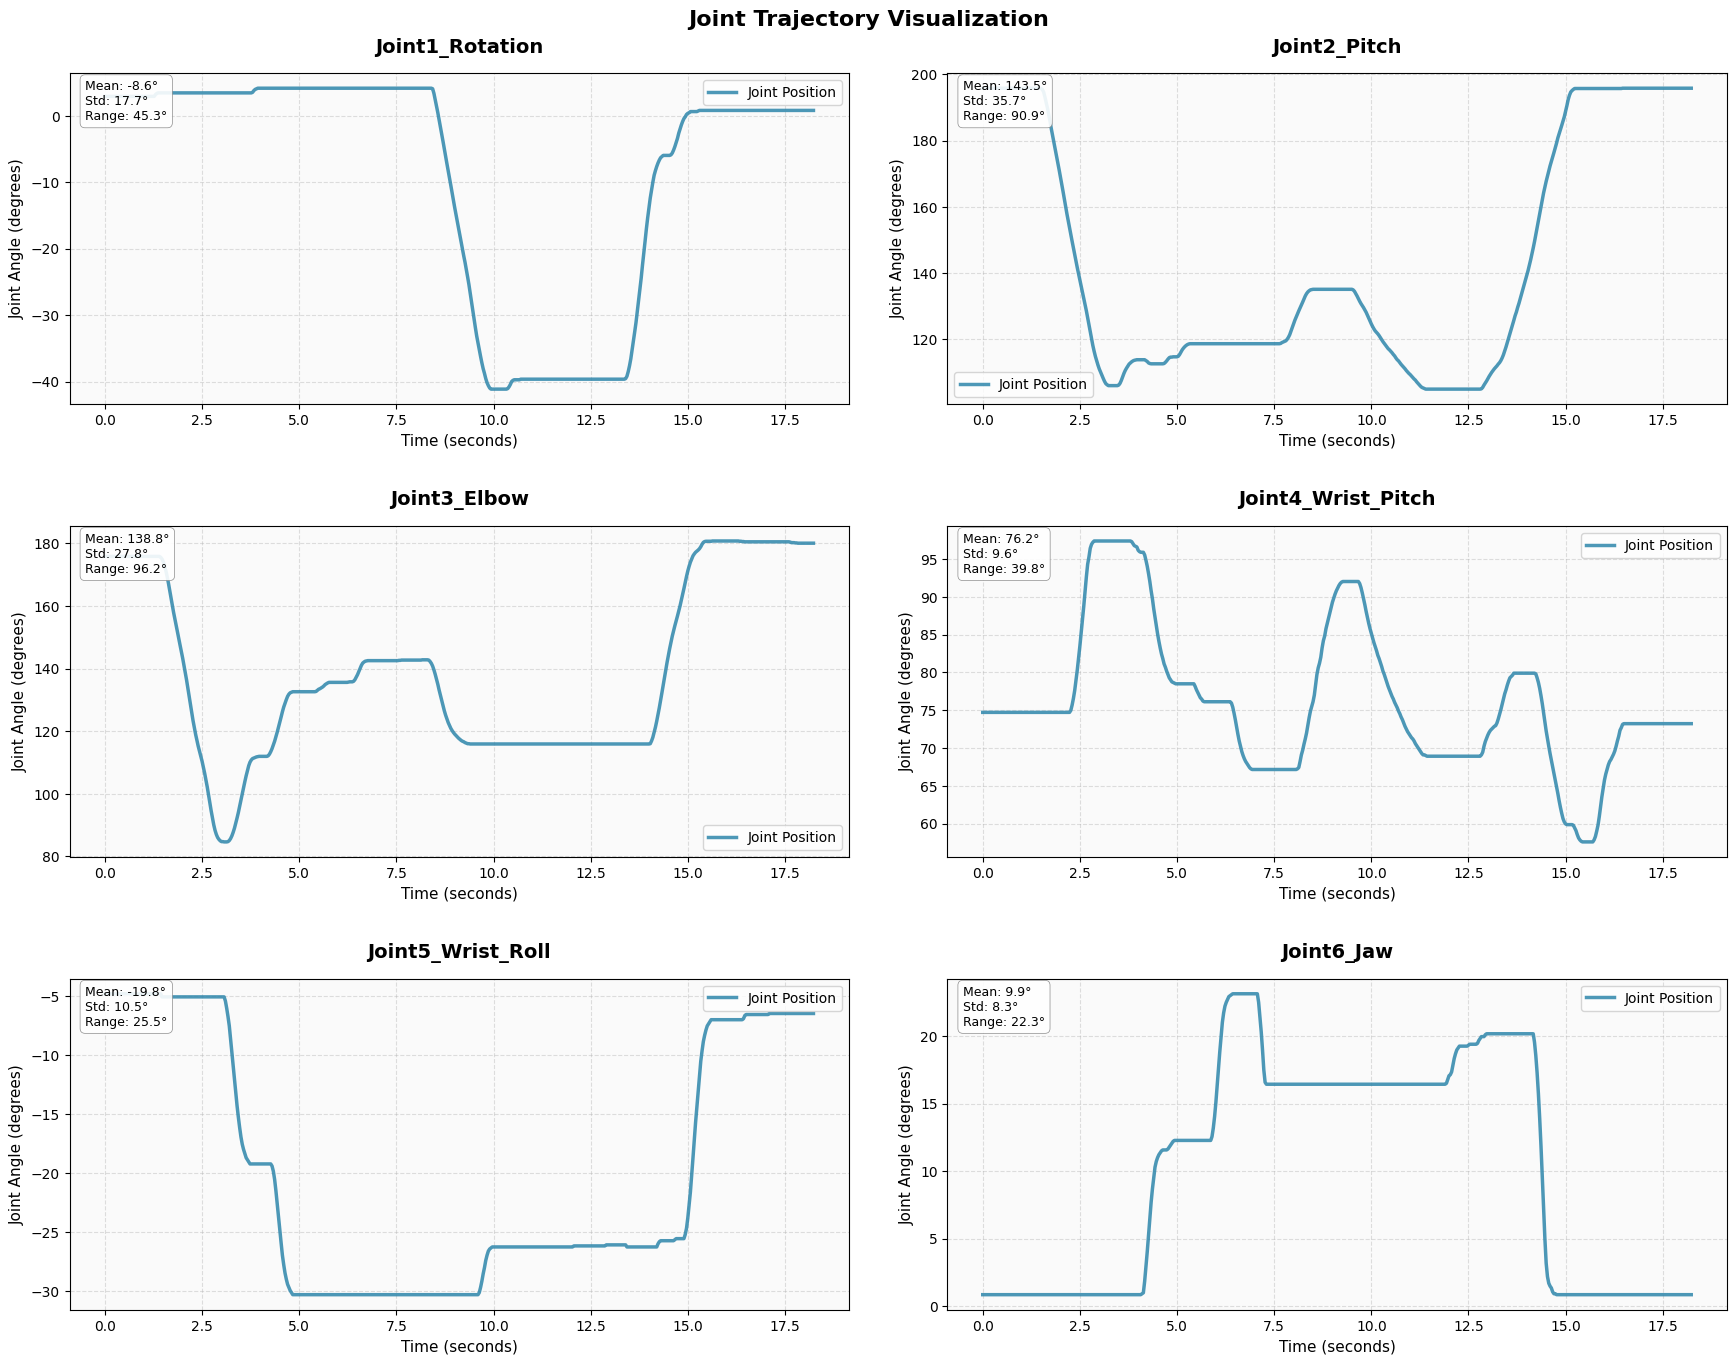

✅ Trajectory plots created successfully
📊 TRAJECTORY SUMMARY:
   Duration: 18.2 seconds
   Frames: 548
   Sampling rate: 30.1 Hz
   Joint dimensions: 6
✅ Trajectory data saved to ./output/trajectory.h5


In [25]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Define the path to your HDF5 file.
# The original commented path was: '/projects/0/prjs0951/LeRobot_dataset/data/test_episode/trajectory.h5'
path = './output/converted_episodic.h5'

# Define the names for the robot joints to be used in plot titles.
JOINT_NAMES = [
    "Joint1_Rotation",
    "Joint2_Pitch",
    "Joint3_Elbow",
    "Joint4_Wrist_Pitch",
    "Joint5_Wrist_Roll",
    "Joint6_Jaw"
]

def visualize_h5_trajectory(path, JOINT_NAMES):
    """
    Reads trajectory data from an HDF5 file, visualizes the joint movements,
    and saves a summary HDF5 file.

    Args:
        path (str): The file path to the input HDF5 file.
        JOINT_NAMES (list): A list of strings with names for each joint.
    """
    try:
        with h5py.File(path, 'r') as f:
            # --- FIX ---
            # Correctly access the datasets within the HDF5 file.
            # The original code used f['...']['0'], which is not the correct syntax for h5py.
            # The correct way is to include the episode key ('0') in the main path.
            # We also add [()] to load the data into a NumPy array immediately.
            episode_key = '0'
            timestamps = f[f'metadata/timestamp/{episode_key}'][()]
            frame_indices = f[f'metadata/frame_index/{episode_key}'][()]
            gripper_positions = f[f'observation/robot_state/gripper_position/{episode_key}'][()]
            joint_positions = f[f'observation/robot_state/cartesian_position/{episode_key}'][()]

            print(f"Shape of joint positions data: {joint_positions.shape}")

            # Create time axis from timestamps.
            time_axis = timestamps
            n_frames = len(timestamps)
            duration = timestamps[-1] - timestamps[0] if len(timestamps) > 1 else 0

            print(f"📐 Plotting {n_frames} frames ({duration:.1f} seconds)")
            print(f"📊 Gripper positions: {gripper_positions.shape}")
            print(f"📊 Joint positions: {joint_positions.shape}")
            print(f"📊 Timestamps: {timestamps.shape}")
            print(f"📊 Frame indices: {frame_indices.shape}")

            # Create a 3x2 subplot layout for the joint visualizations.
            fig, axes = plt.subplots(3, 2, figsize=(18, 14))
            axes = axes.flatten()

            # Define colors for the plot elements.
            joint_color = '#2E86AB'  # A nice blue for the joint data.

            # Plot each joint's trajectory.
            n_joints = min(joint_positions.shape[1], 6)  # Ensure we don't exceed 6 plots.

            for i in range(n_joints):
                ax = axes[i]

                # --- FIX ---
                # The original code had a comment about converting to degrees but didn't perform the operation.
                # Added np.rad2deg() to match the plot's y-axis label.
                joint_deg = joint_positions[:, i]

                # Plot the joint trajectory over time.
                ax.plot(time_axis, joint_deg, color=joint_color, linewidth=2.5,
                        label='Joint Position', alpha=0.85)

                # Style the subplot for clarity and aesthetics.
                joint_name = JOINT_NAMES[i] if i < len(JOINT_NAMES) else f'Joint {i+1}'
                ax.set_title(f'{joint_name}', fontsize=14, fontweight='bold', pad=15)
                ax.set_xlabel('Time (seconds)', fontsize=11)
                ax.set_ylabel('Joint Angle (degrees)', fontsize=11)
                ax.legend(fontsize=10, loc='best')
                ax.grid(True, linestyle='--', alpha=0.4)
                ax.set_facecolor('#FAFAFA')

                # Calculate and display statistics for each joint.
                mean_val = np.mean(joint_deg)
                std_val = np.std(joint_deg)
                range_val = np.max(joint_deg) - np.min(joint_deg)

                # Create a formatted text box for the statistics.
                stats_text = f'Mean: {mean_val:.1f}°\nStd: {std_val:.1f}°\nRange: {range_val:.1f}°'
                ax.text(0.02, 0.98, stats_text,
                        transform=ax.transAxes,
                        verticalalignment='top',
                        fontsize=9,
                        bbox=dict(boxstyle='round,pad=0.4',
                                  facecolor='white',
                                  alpha=0.9,
                                  edgecolor='gray',
                                  linewidth=0.5))

            # Hide any unused subplots if there are fewer than 6 joints.
            for i in range(n_joints, 6):
                axes[i].set_visible(False)

            plt.tight_layout(pad=3.0)
            plt.suptitle('Joint Trajectory Visualization',
                         fontsize=16, fontweight='bold', y=0.99)
            plt.show()

            # Print a summary of the trajectory data.
            print("✅ Trajectory plots created successfully")
            print("📊 TRAJECTORY SUMMARY:")
            print(f"   Duration: {duration:.1f} seconds")
            print(f"   Frames: {n_frames}")
            if duration > 0:
                print(f"   Sampling rate: {n_frames/duration:.1f} Hz")
            print(f"   Joint dimensions: {joint_positions.shape[1]}")

            # --- Data Saving Section ---
            # This section saves the loaded data into a new HDF5 file with a different structure.
            output_path = './output/trajectory.h5'
            with h5py.File(output_path, 'w') as f_out:
                # Create groups for organizing the data.
                metadata_group = f_out.create_group('metadata')
                observation_group = f_out.create_group('observation')
                robot_state_group = observation_group.create_group('robot_state')

                # Store the data into the new file.
                robot_state_group.create_dataset('cartesian_position',
                                                 data=joint_positions.astype(np.float64))
                robot_state_group.create_dataset('gripper_position',
                                                 data=gripper_positions.astype(np.float64))
                metadata_group.create_dataset('timestamp', data=timestamps)
                metadata_group.create_dataset('frame_index', data=frame_indices)
            print(f"✅ Trajectory data saved to {output_path}")

    except FileNotFoundError:
        print(f"Error: The file was not found at {path}")
    except KeyError as e:
        print(f"Error: A dataset or group was not found in the HDF5 file: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Run the visualization function.
visualize_h5_trajectory(path, JOINT_NAMES)

Processing dataset 0
🔄 Converting dataset to H5 format with episodic dictionary structure: ./output/test_dataset_0.h5
📊 Dataset size: 64505
✅ Found 135 episodes
📊 Episode lengths: min=211, max=894, mean=477.8
✅ Found joint positions: (64505, 6) -> creating dictionary structure
✅ Found gripper data: (64505, 6)
🔄 Creating episodic dictionary structure...
✅ Created episodic dictionary structure:
   📊 Number of episodes: 135
   📊 Episode keys: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '

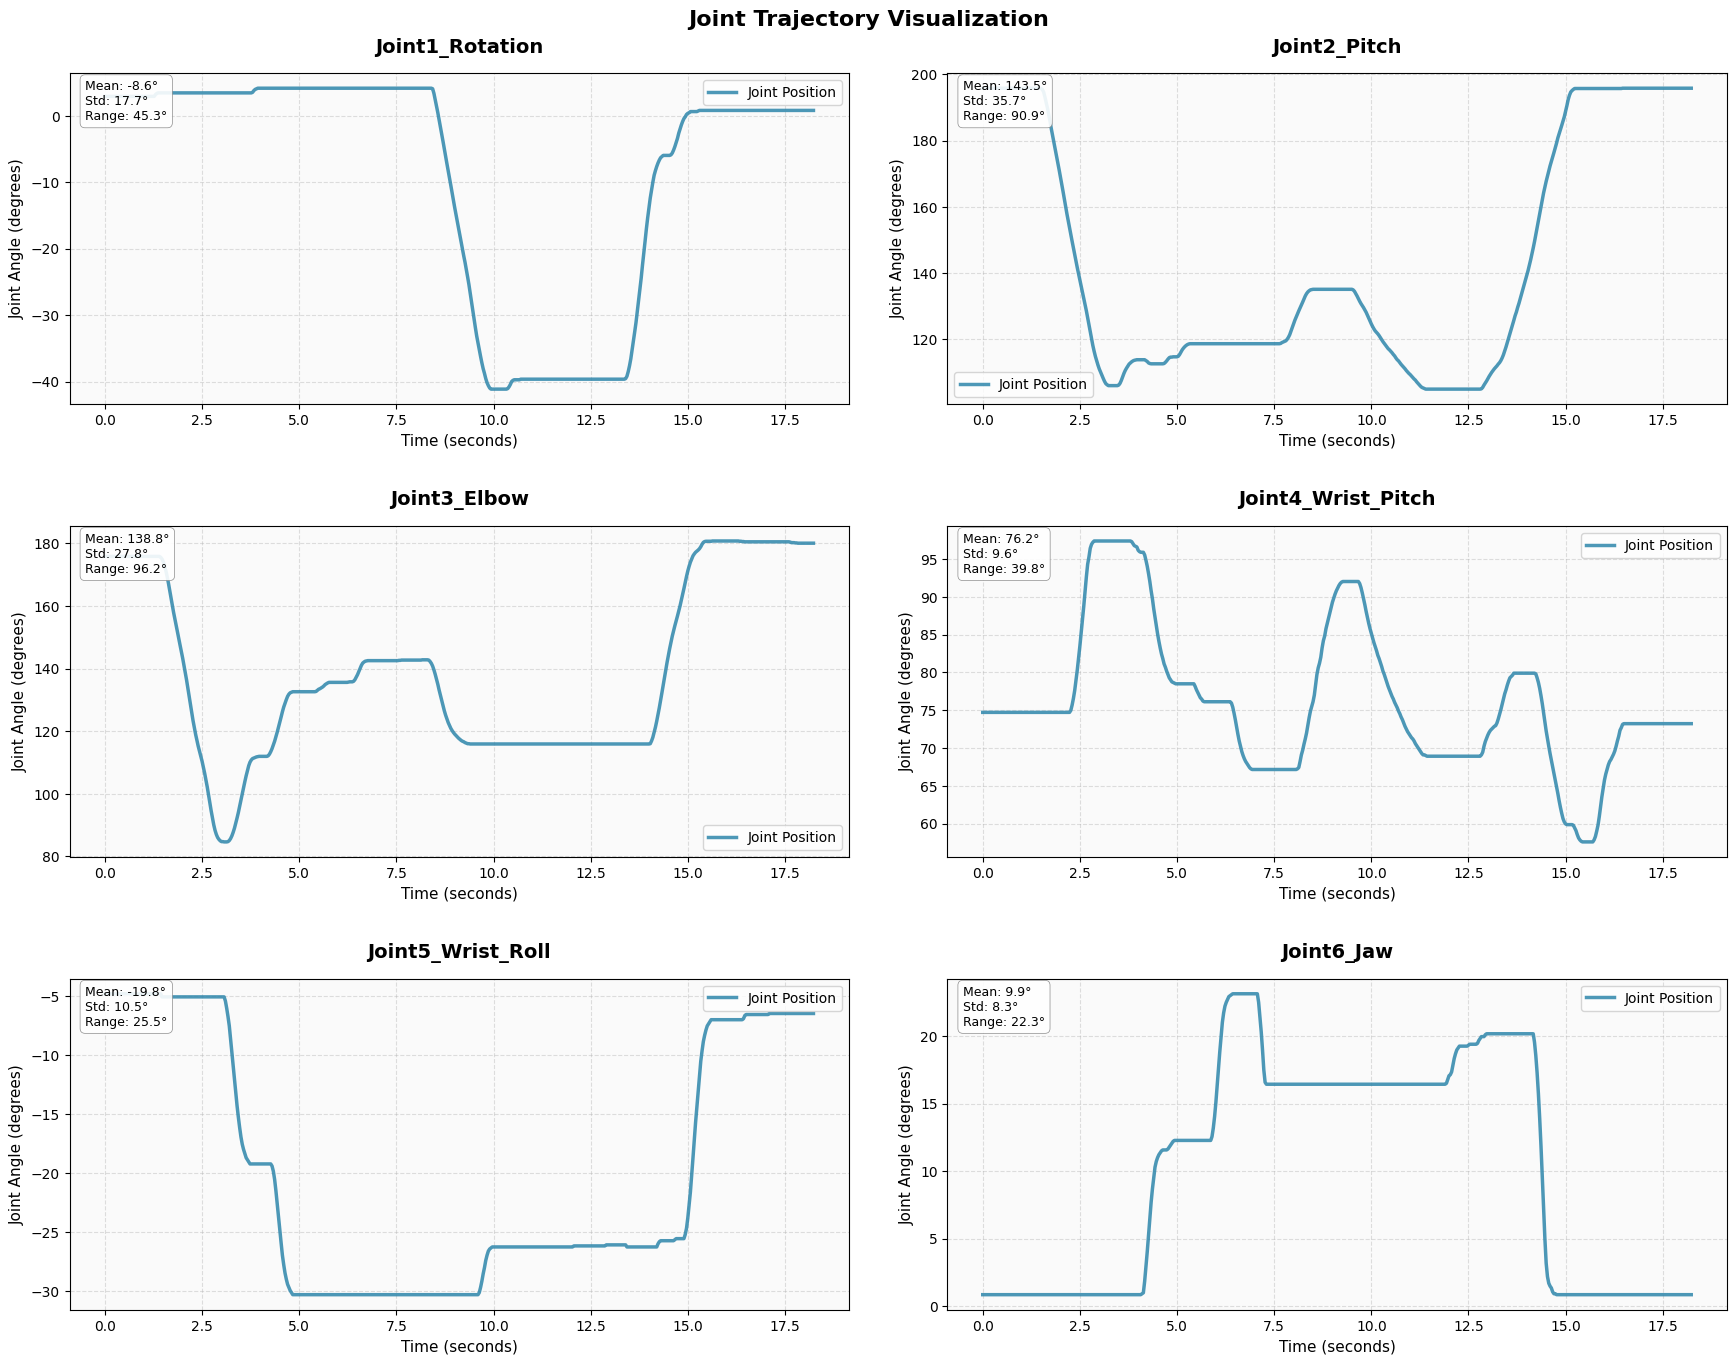

✅ Trajectory plots created successfully
📊 TRAJECTORY SUMMARY:
   Duration: 18.2 seconds
   Frames: 548
   Sampling rate: 30.1 Hz
   Joint dimensions: 6
✅ Trajectory data saved to ./output/trajectory.h5
Processing dataset 1
🔄 Converting dataset to H5 format with episodic dictionary structure: ./output/test_dataset_1.h5
📊 Dataset size: 510641
✅ Found 899 episodes
📊 Episode lengths: min=358, max=1194, mean=568.0
✅ Found joint positions: (510641, 6) -> creating dictionary structure
✅ Found gripper data: (510641, 6)
🔄 Creating episodic dictionary structure...
✅ Created episodic dictionary structure:
   📊 Number of episodes: 899
   📊 Episode keys: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59',

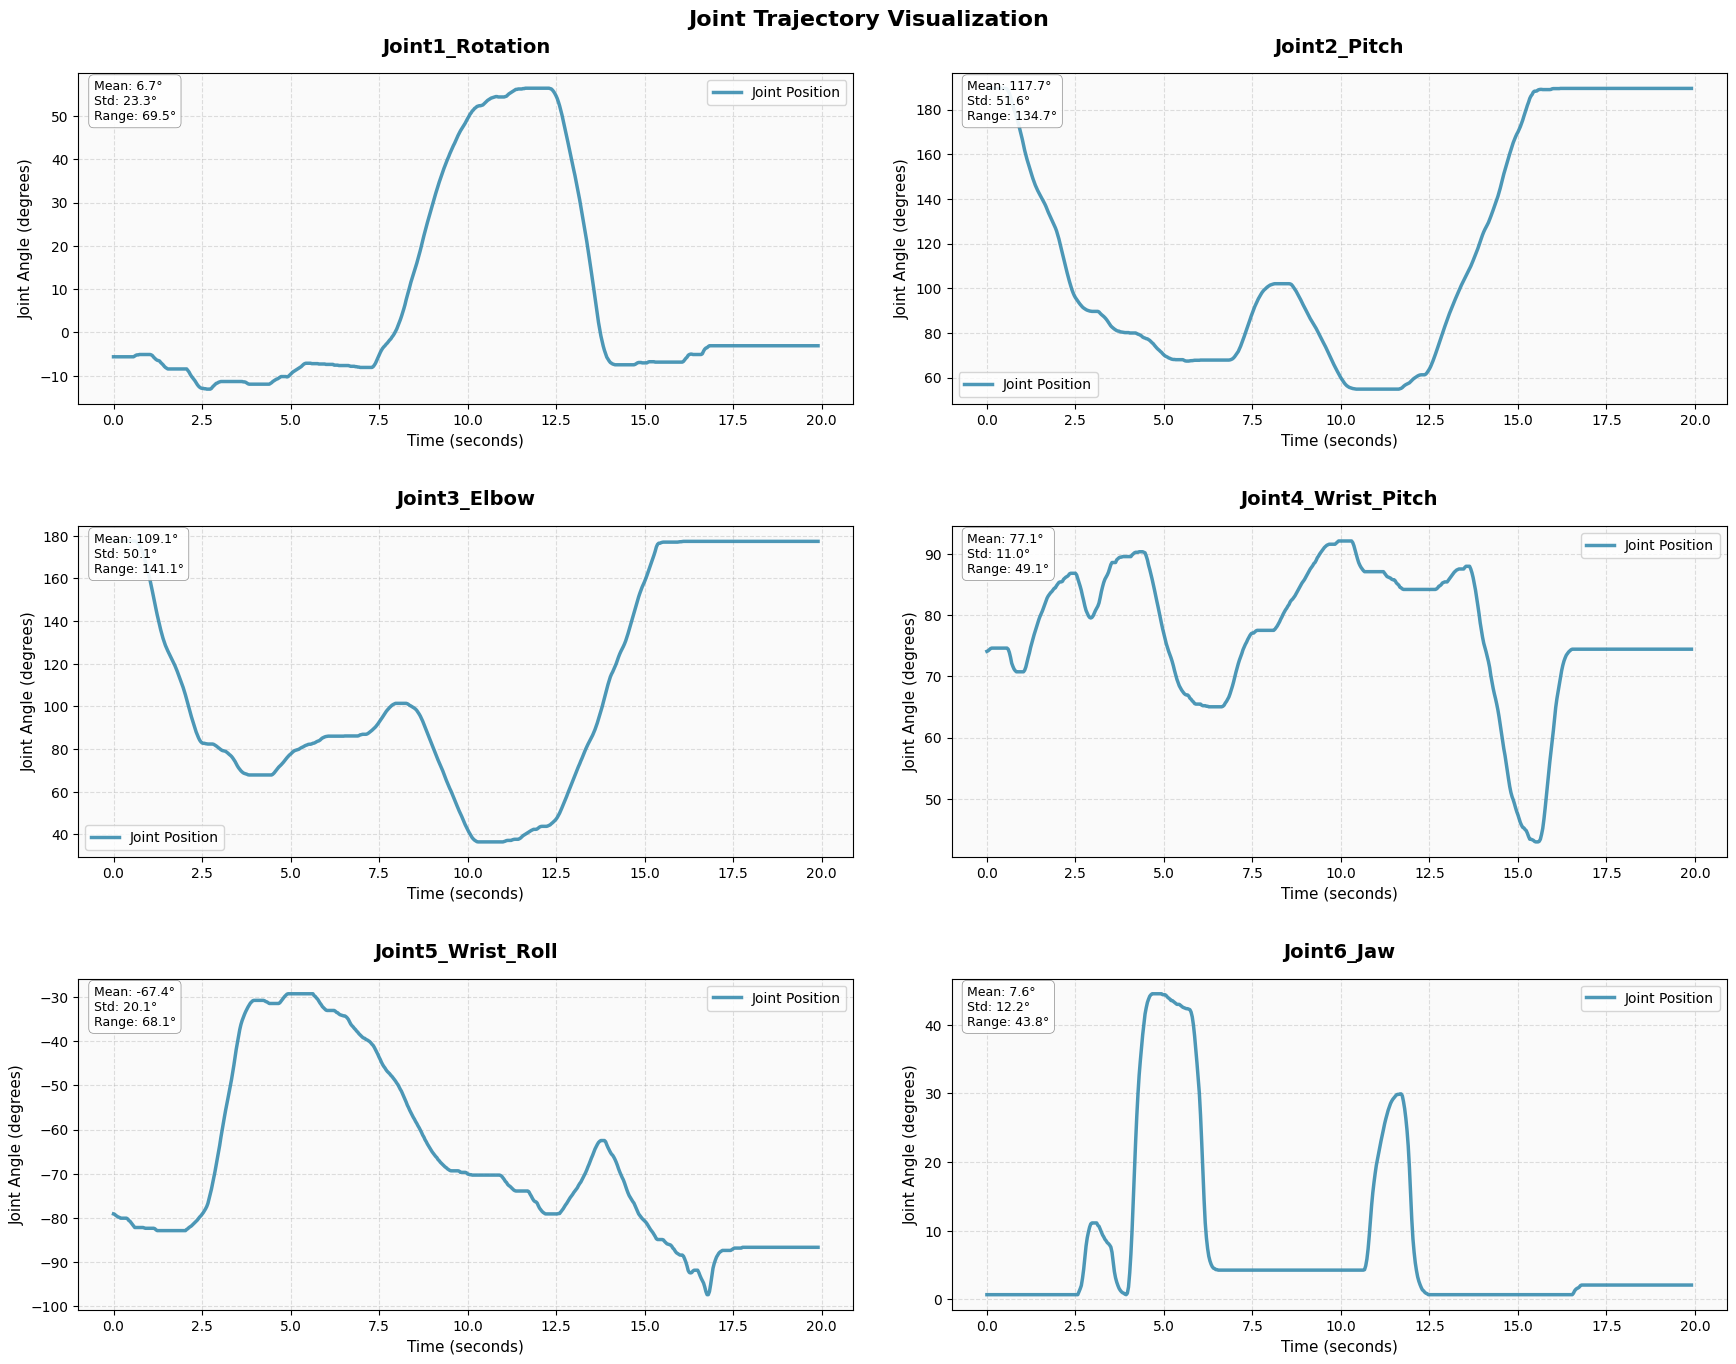

✅ Trajectory plots created successfully
📊 TRAJECTORY SUMMARY:
   Duration: 19.9 seconds
   Frames: 598
   Sampling rate: 30.1 Hz
   Joint dimensions: 6
✅ Trajectory data saved to ./output/trajectory.h5
Processing dataset 2
🔄 Converting dataset to H5 format with episodic dictionary structure: ./output/test_dataset_2.h5
📊 Dataset size: 21648
✅ Found 100 episodes
📊 Episode lengths: min=1, max=435, mean=216.5
✅ Found joint positions: (21648, 6) -> creating dictionary structure
✅ Found gripper data: (21648, 6)
🔄 Creating episodic dictionary structure...
✅ Created episodic dictionary structure:
   📊 Number of episodes: 100
   📊 Episode keys: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',

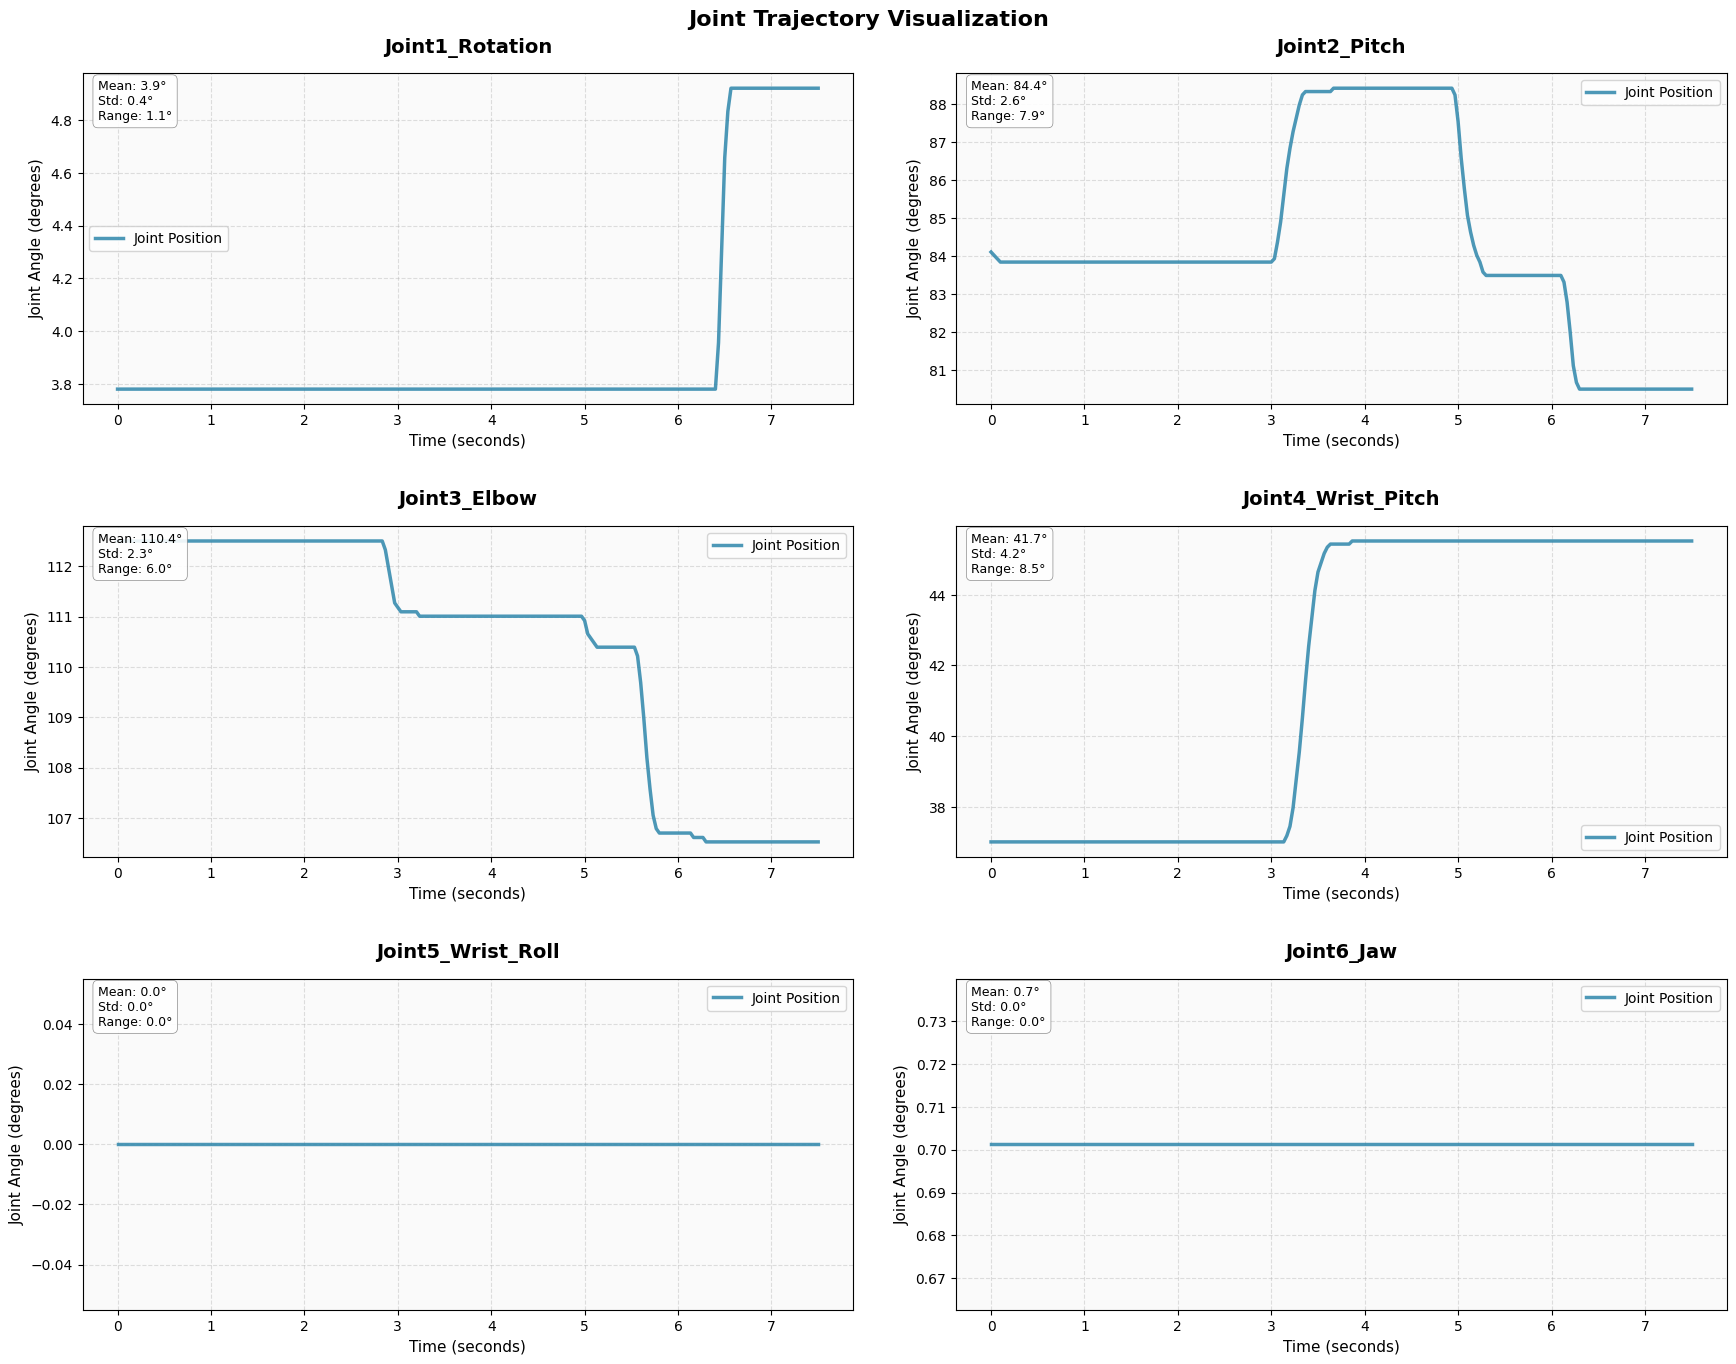

✅ Trajectory plots created successfully
📊 TRAJECTORY SUMMARY:
   Duration: 7.5 seconds
   Frames: 226
   Sampling rate: 30.1 Hz
   Joint dimensions: 6
✅ Trajectory data saved to ./output/trajectory.h5
Processing dataset 3
🔄 Converting dataset to H5 format with episodic dictionary structure: ./output/test_dataset_3.h5
📊 Dataset size: 98999
✅ Found 252 episodes
📊 Episode lengths: min=76, max=449, mean=392.9
✅ Found joint positions: (98999, 6) -> creating dictionary structure
✅ Found gripper data: (98999, 6)
🔄 Creating episodic dictionary structure...
✅ Created episodic dictionary structure:
   📊 Number of episodes: 252
   📊 Episode keys: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',

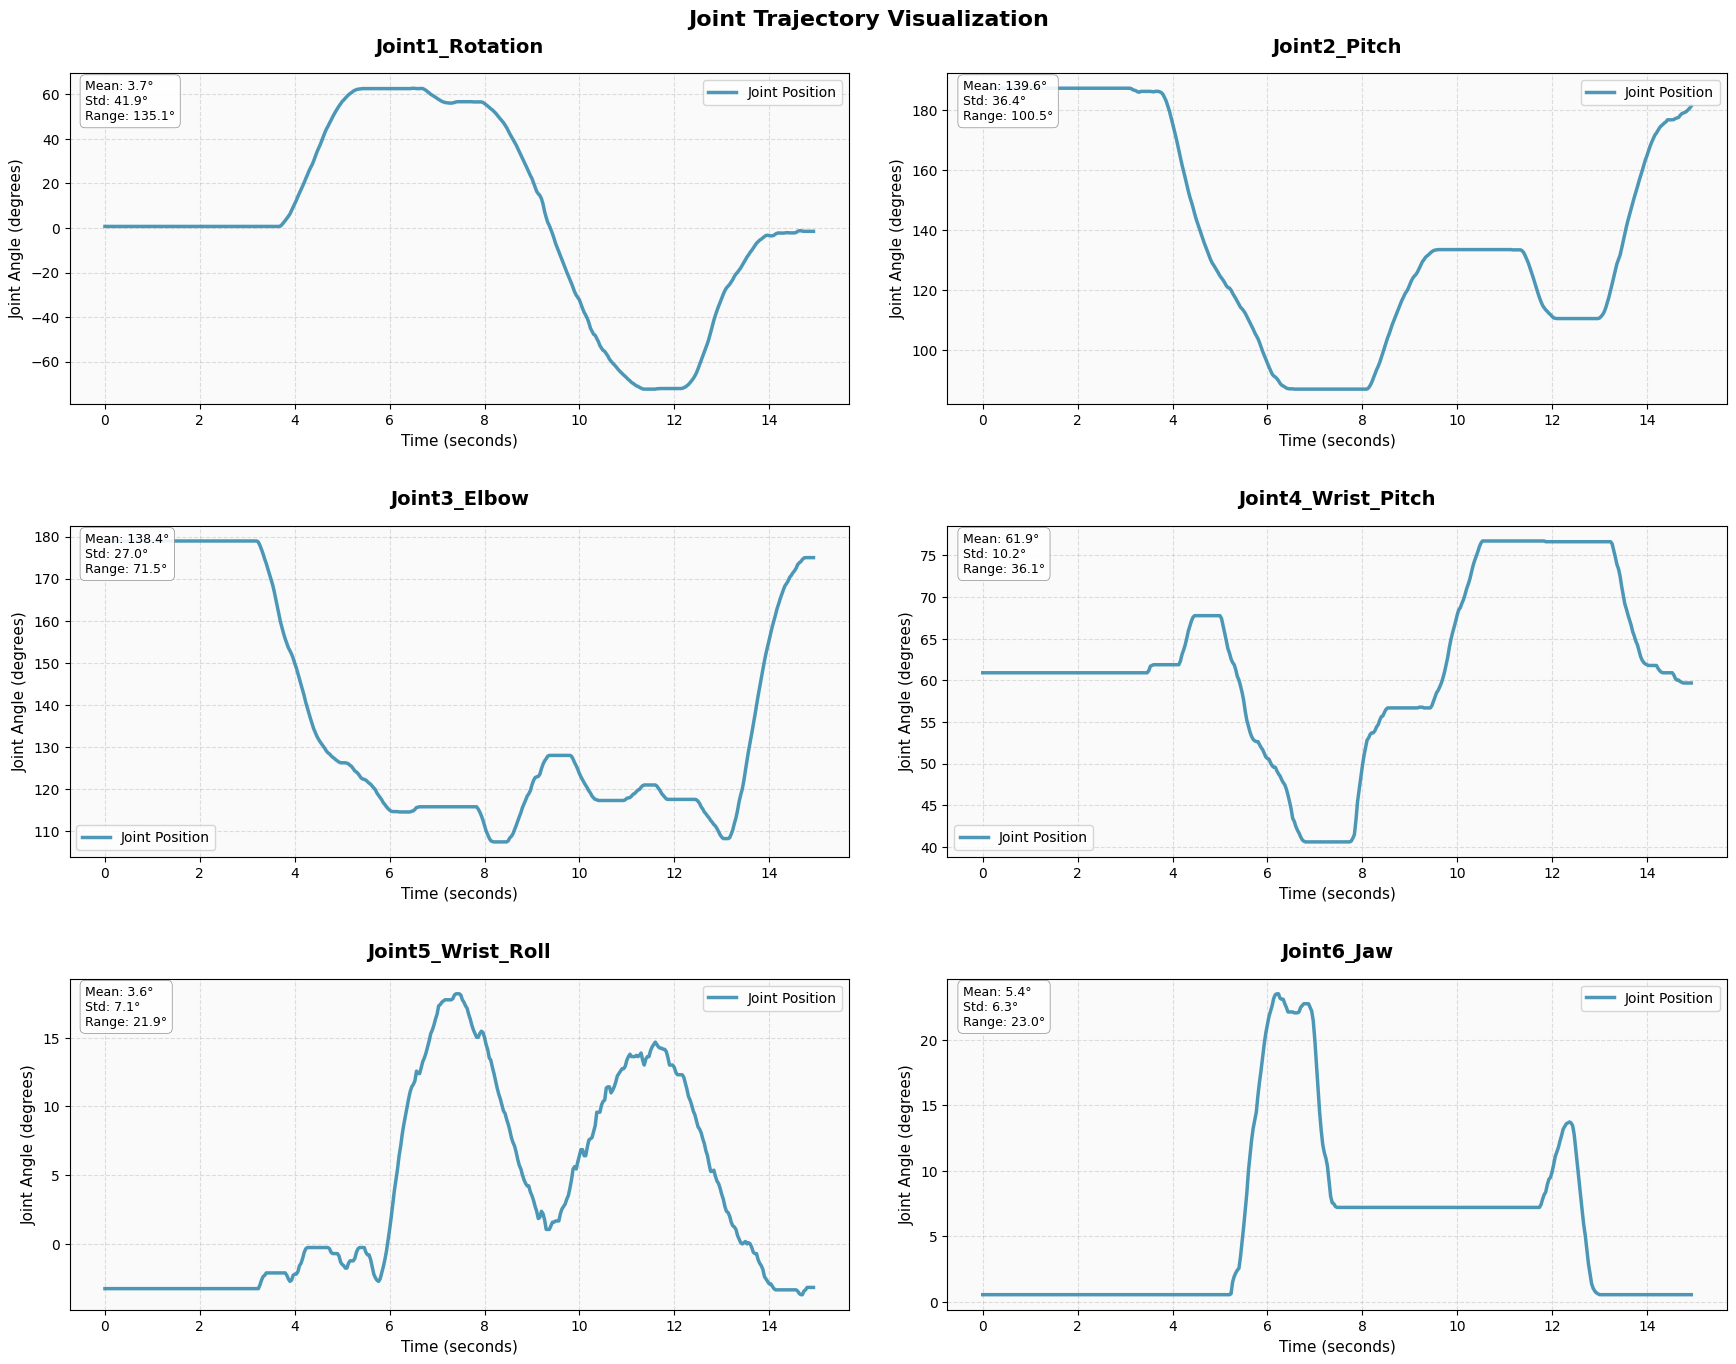

✅ Trajectory plots created successfully
📊 TRAJECTORY SUMMARY:
   Duration: 14.9 seconds
   Frames: 449
   Sampling rate: 30.1 Hz
   Joint dimensions: 6
✅ Trajectory data saved to ./output/trajectory.h5


In [31]:
JOINT_NAMES = [
    "Joint1_Rotation",
    "Joint2_Pitch",
    "Joint3_Elbow",
    "Joint4_Wrist_Pitch",
    "Joint5_Wrist_Roll",
    "Joint6_Jaw"
]

datasets = [dataset['train'], ds_1['train'], ds_2['train'], ds_3['train']]
for i in range(4):
    print(f"Processing dataset {i}")
    output_file = f"./output/test_dataset_{i}.h5"
    convert_dataset_to_h5(datasets[i], output_file)
    verify_h5_structure(output_file)
    visualize_h5_trajectory(output_file, JOINT_NAMES)